In [4]:
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [15]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw"
SEA_ANIMALS = RAW_DATA / "sea-animals"
PLASTIC = RAW_DATA / "marine-plastic" / "SOUVIK"

In [ ]:
print(f"Project Root: {PROJECT_ROOT}")
print(f"Raw Data: {RAW_DATA}")
print(f"Sea Animals: {SEA_ANIMALS}")
print(f"Marine Plastic: {PLASTIC}")
print(f"Sea Animals exists: {SEA_ANIMALS.exists()}")
print(f"Marine Plastic exists: {PLASTIC.exists()}")

print("Sea Animal Categories:\n")
for folder in SEA_ANIMALS.iterdir():
    if folder.is_dir():
        print(folder.name)

Project Root: d:\Code\Internship_code\marine-debris-classifier
Raw Data: d:\Code\Internship_code\marine-debris-classifier\data\raw
Sea Animals: d:\Code\Internship_code\marine-debris-classifier\data\raw\sea-animals
Marine Plastic: d:\Code\Internship_code\marine-debris-classifier\data\raw\marine-plastic
Sea Animals exists: True
Marine Plastic exists: True
Sea Animal Categories:

Clams
Corals
Crabs
Dolphin
Eel
Fish
Jelly Fish
Lobster
Nudibranchs
Octopus
Otter
Penguin
Puffers
Sea Rays
Sea Urchins
Seahorse
Seal
Sharks
Shrimp
Squid
Starfish
Turtle_Tortoise
Whale


In [16]:
image_count = 0
for folder in SEA_ANIMALS.iterdir():
    if folder.is_dir():
        images = list(folder.glob("*"))
        print(f"{folder.name}:{len(images)} images")
        image_count += len(images)
print(f"\nTOtal Marine Life Images:{image_count}")

Clams:497 images
Corals:500 images
Crabs:499 images
Dolphin:782 images
Eel:497 images
Fish:494 images
Jelly Fish:845 images
Lobster:499 images
Nudibranchs:500 images
Octopus:562 images
Otter:500 images
Penguin:482 images
Puffers:531 images
Sea Rays:517 images
Sea Urchins:579 images
Seahorse:478 images
Seal:414 images
Sharks:590 images
Shrimp:488 images
Squid:483 images
Starfish:499 images
Turtle_Tortoise:1903 images
Whale:572 images

TOtal Marine Life Images:13711


In [17]:
for split in PLASTIC.iterdir():
    print(split.name)

    if split.is_dir():
        for folder in split.iterdir():
            print("   ", folder.name)

test
    no-plastic
    plastic
train
    no-plastic
    plastic


In [ ]:
PROCESSED = PROJECT_ROOT / "data" / "processed"

MARINE_OUT = PROCESSED / "Marine_Life"
PLASTIC_OUT = PROCESSED / "Plastic"

MARINE_OUT.mkdir(parents=True, exist_ok=True)
PLASTIC_OUT.mkdir(parents=True, exist_ok=True)

print("Processed folders created!")


Processed folders created!


In [19]:
from PIL import Image
from pathlib import Path

TARGET_SIZE = (224, 224)

marine_images = []

# Collect every marine life image
for category in SEA_ANIMALS.iterdir():
    if category.is_dir():
        marine_images.extend(category.glob("*.jpg"))
        marine_images.extend(category.glob("*.jpeg"))
        marine_images.extend(category.glob("*.png"))

plastic_images = []

# Collect plastic images from train and test
for split in ["train", "test"]:
    plastic_folder = PLASTIC / split / "plastic"

    plastic_images.extend(plastic_folder.glob("*.jpg"))
    plastic_images.extend(plastic_folder.glob("*.jpeg"))
    plastic_images.extend(plastic_folder.glob("*.png"))

print(f"Marine images: {len(marine_images)}")
print(f"Plastic images: {len(plastic_images)}")

limit = min(len(marine_images), len(plastic_images))

print(f"Using {limit} images from each class.")

Marine images: 13711
Plastic images: 1050
Using 1050 images from each class.


In [20]:
TARGET_SIZE = (224, 224)

print("Processing Marine Life images...")

for i, image_path in enumerate(marine_images[:limit]):

    img = Image.open(image_path)

    img = img.convert("RGB")

    img = img.resize(TARGET_SIZE)

    img.save(MARINE_OUT / f"marine_{i:04}.jpg")


print("Processing Plastic images...")

for i, image_path in enumerate(plastic_images[:limit]):

    img = Image.open(image_path)

    img = img.convert("RGB")

    img = img.resize(TARGET_SIZE)

    img.save(PLASTIC_OUT / f"plastic_{i:04}.jpg")


print("Dataset preprocessing complete!")
print(f"Marine Life images saved: {limit}")
print(f"Plastic images saved: {limit}")

Processing Marine Life images...
Processing Plastic images...
Dataset preprocessing complete!
Marine Life images saved: 1050
Plastic images saved: 1050


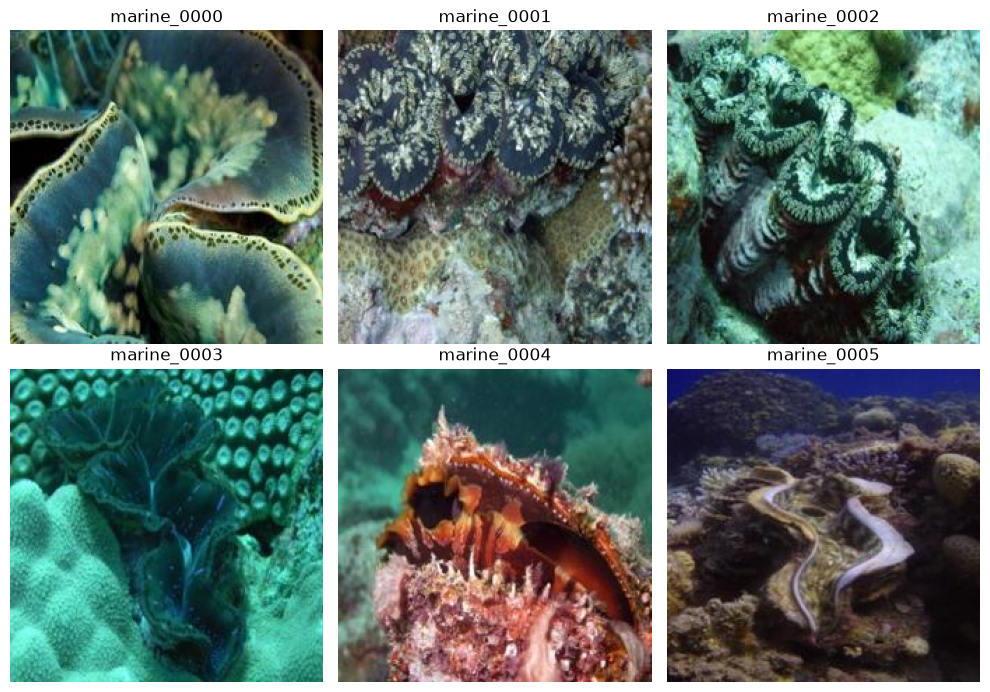

In [21]:
sample_images = list(MARINE_OUT.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax, image_path in zip(axes.flatten(), sample_images):

    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(image_path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

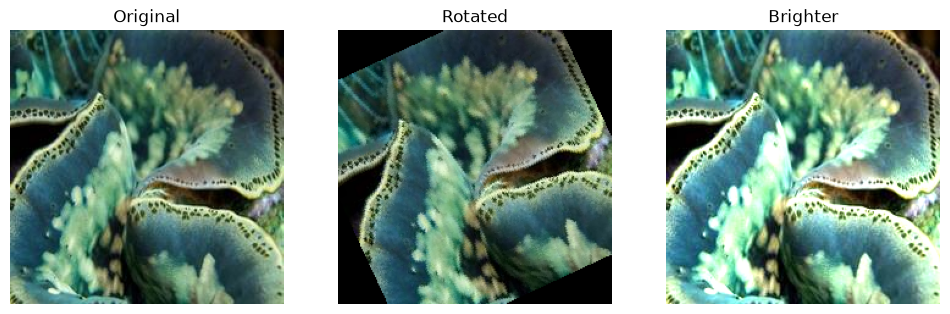

In [23]:
from PIL import ImageEnhance
import random
sample = Image.open(sample_images[0])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(sample)
plt.title("Original")
plt.axis("off")

rotated = sample.rotate(25)

plt.subplot(1,3,2)
plt.imshow(rotated)
plt.title("Rotated")
plt.axis("off")

enhancer = ImageEnhance.Brightness(sample)
bright = enhancer.enhance(1.5)

plt.subplot(1,3,3)
plt.imshow(bright)
plt.title("Brighter")
plt.axis("off")

plt.show()